In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185,

In [28]:
import importlib
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

import monk_common as mc
import knn_common as kc
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


In [3]:
importlib.reload(mc)
importlib.reload(kc)

<module 'knn_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/collaudo/knn_common.py'>

In [30]:
# Split for KFold
n_split = 5
default_cv = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)

default_krange = list(range(1, 41, 2))

weights = "uniform"
metric = "euclidean"


<h2>Exploring Dataset</h2>
<hr/>

<h3>Monk 1</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [5]:
monk_1_TR_orig, monk_1_TS_orig = mc.load_set(1)
monk_1_TR_features, monk_1_TR_labels = mc.split_and_prepare_dataset(monk_1_TR_orig)
monk_1_TS_features, monk_1_TS_labels = mc.split_and_prepare_dataset(monk_1_TS_orig)
mc.dataset_introspection(monk_1_TR_orig, monk_1_TS_orig)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


In [6]:
model_1, cv_scores_1, train_scores_1 = kc.find_best_knn_model(
    monk_1_TR_features, monk_1_TR_labels, default_cv, default_krange
)

best_k, best_mean, best_std = kc.knn_introspection(cv_scores_1)


Best k: 5
Best mean accuracy: 0.782
Std: 0.042142615011410964


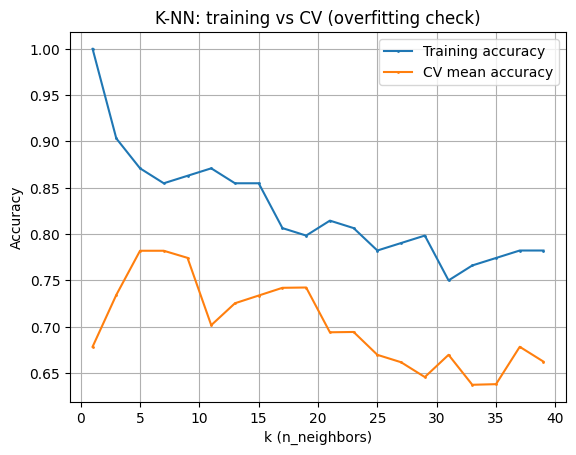

In [7]:
kc.plot_knn_validation_curve(cv_scores_1, train_scores_1)

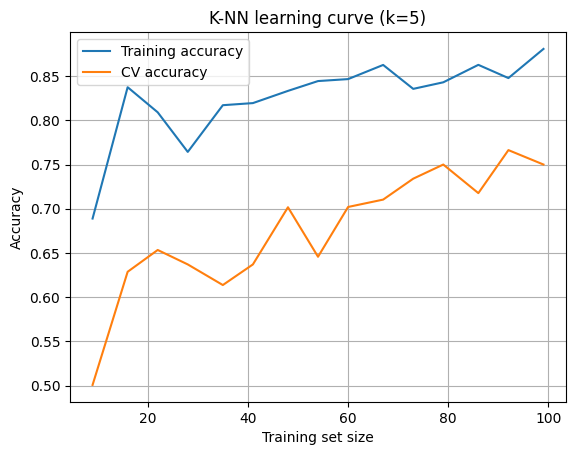

In [8]:
kc.plot_knn_learning_curve(model_1, monk_1_TR_features, monk_1_TR_labels, default_cv)

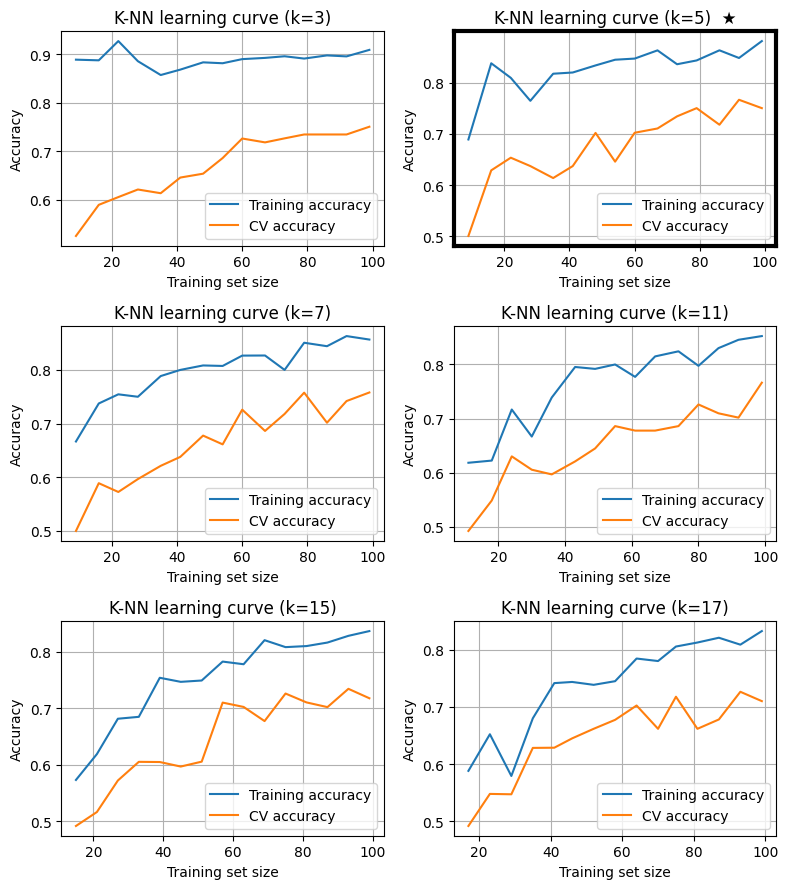

In [32]:

models=[]
for k in kc.k_neighborhood(best_k, len(monk_1_TR_labels)):
    models.append(KNeighborsClassifier(
        n_neighbors=k,
        weights=weights,
        metric=metric
    ))

kc.plot_knn_learning_curves_grid(
    models=models,
    X=monk_1_TR_features,
    y=monk_1_TR_labels,
    cv=default_cv,
    highlight_k=best_k
)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [9]:
model_1.fit(monk_1_TR_features, monk_1_TR_labels)
monk_1_TS_labels_pred = model_1.predict(monk_1_TS_features)

In [10]:
print(classification_report(monk_1_TS_labels, monk_1_TS_labels_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81       216
           1       0.84      0.76      0.80       216

    accuracy                           0.81       432
   macro avg       0.81      0.81      0.81       432
weighted avg       0.81      0.81      0.81       432



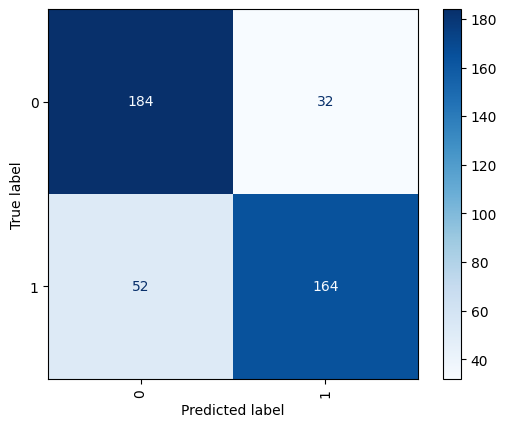

In [11]:
ConfusionMatrixDisplay.from_predictions(monk_1_TS_labels, monk_1_TS_labels_pred, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 2</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [12]:
monk_2_TR_orig, monk_2_TS_orig = mc.load_set(2)
monk_2_TR_features, monk_2_TR_labels = mc.split_and_prepare_dataset(monk_2_TR_orig)
monk_2_TS_features, monk_2_TS_labels = mc.split_and_prepare_dataset(monk_2_TS_orig)
mc.dataset_introspection(monk_2_TR_orig, monk_2_TS_orig)

,Property,Training,Test
0,Number of samples,169,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 105, class 1 = 64","class 0 = 290, class 1 = 142"


<h4>Model Selection</h4>
<p>Find the best K model.</p>

In [13]:
model_2, cv_scores_2, train_scores_2 = kc.find_best_knn_model(
    monk_2_TR_features, monk_2_TR_labels, default_cv, default_krange
)

best_k_2, best_mean_2, best_std_2 = kc.knn_introspection(cv_scores_2)

Best k: 21
Best mean accuracy: 0.6926916221033869
Std: 0.058946018421255256


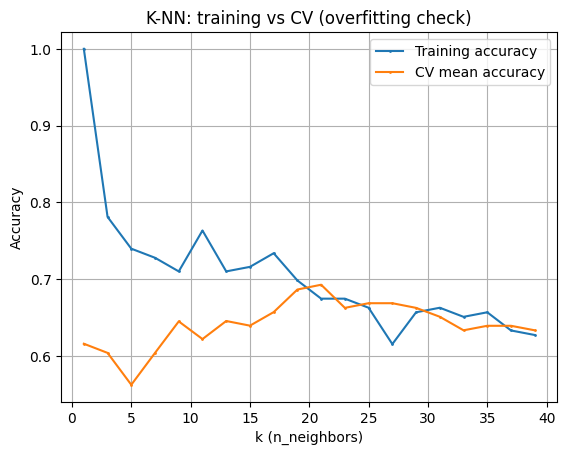

In [14]:
kc.plot_knn_validation_curve(cv_scores_2, train_scores_2)

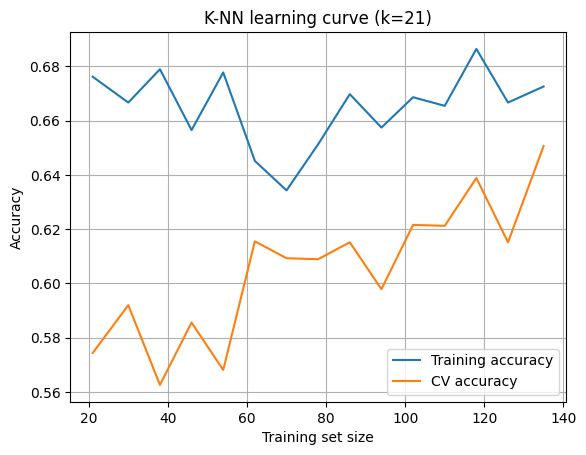

In [15]:
kc.plot_knn_learning_curve(model_2, monk_2_TR_features, monk_2_TR_labels, default_cv)

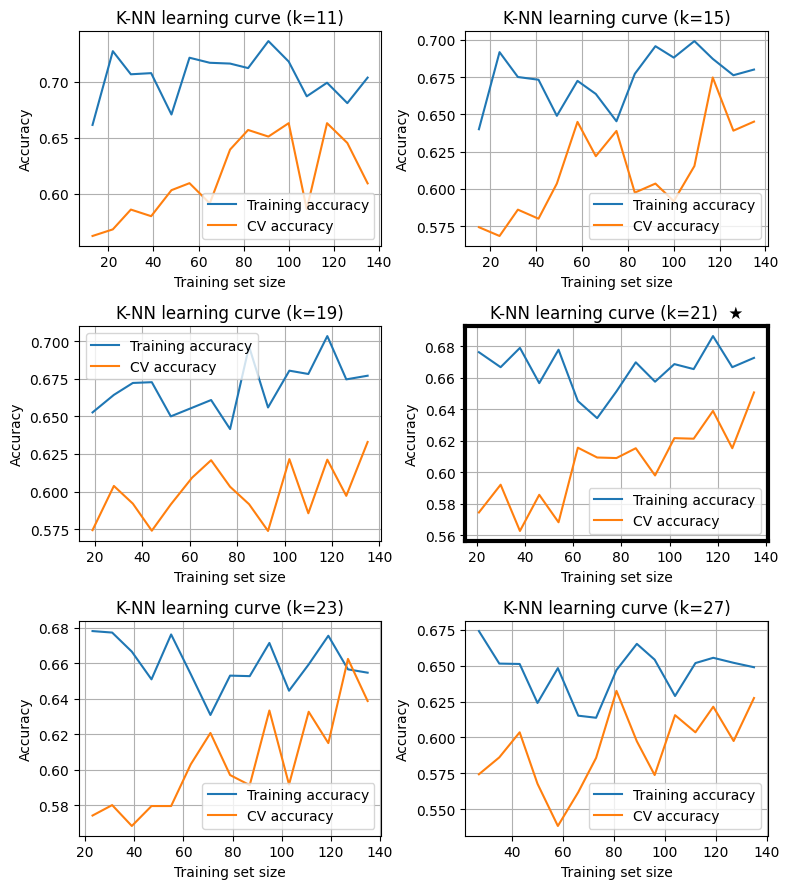

In [33]:
importlib.reload(kc)
models=[]
for k in kc.k_neighborhood(best_k_2, len(monk_2_TR_labels)):
    models.append(KNeighborsClassifier(
        n_neighbors=k,
        weights=weights,
        metric=metric
    ))

kc.plot_knn_learning_curves_grid(
    models=models,
    X=monk_2_TR_features,
    y=monk_2_TR_labels,
    cv=default_cv,
    highlight_k=best_k_2
)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [16]:
model_2.fit(monk_2_TR_features, monk_2_TR_labels)
monk_2_TS_labels_pred = model_2.predict(monk_2_TS_features)

In [17]:
print(classification_report(monk_2_TS_labels, monk_2_TS_labels_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.69      0.87      0.77       290
           1       0.43      0.21      0.28       142

    accuracy                           0.65       432
   macro avg       0.56      0.54      0.53       432
weighted avg       0.61      0.65      0.61       432



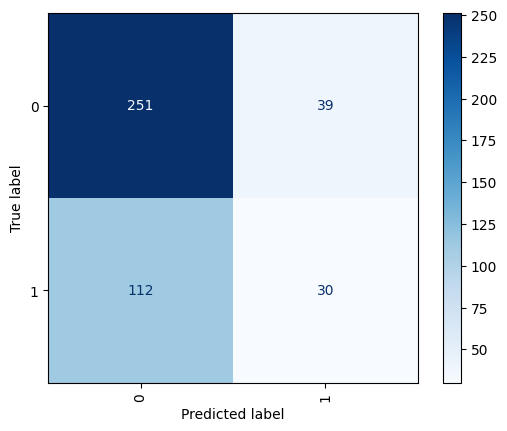

In [18]:
ConfusionMatrixDisplay.from_predictions(monk_2_TS_labels, monk_2_TS_labels_pred, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 3</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [19]:
monk_3_TR_orig, monk_3_TS_orig = mc.load_set(3)
monk_3_TR_features, monk_3_TR_labels = mc.split_and_prepare_dataset(monk_3_TR_orig)
monk_3_TS_features, monk_3_TS_labels = mc.split_and_prepare_dataset(monk_3_TS_orig)
mc.dataset_introspection(monk_3_TR_orig, monk_3_TS_orig)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


<h4>Model Selection</h4>
<p>Find the best K model.</p>

In [20]:
model_3, cv_scores_3, train_scores_3 = kc.find_best_knn_model(
    monk_3_TR_features, monk_3_TR_labels, default_cv, default_krange
)

best_k_3, best_mean_3, best_std_3 = kc.knn_introspection(cv_scores_3)

Best k: 21
Best mean accuracy: 0.8856666666666667
Std: 0.04711215931747934


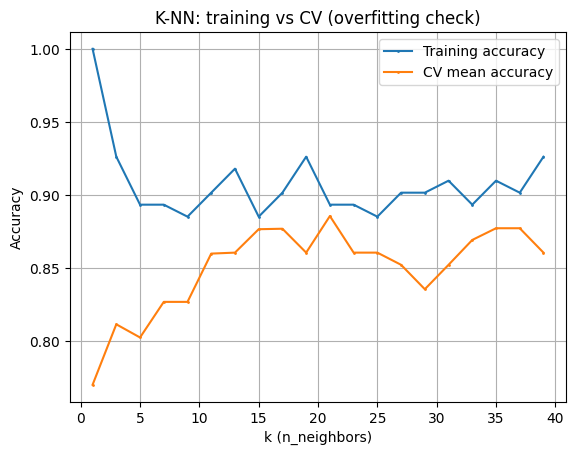

In [21]:
kc.plot_knn_validation_curve(cv_scores_3, train_scores_3)

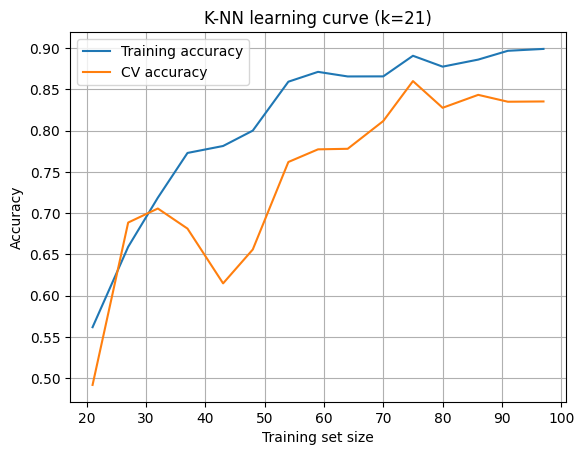

In [22]:
importlib.reload(kc)
kc.plot_knn_learning_curve(model_3, monk_3_TR_features, monk_3_TR_labels, default_cv)

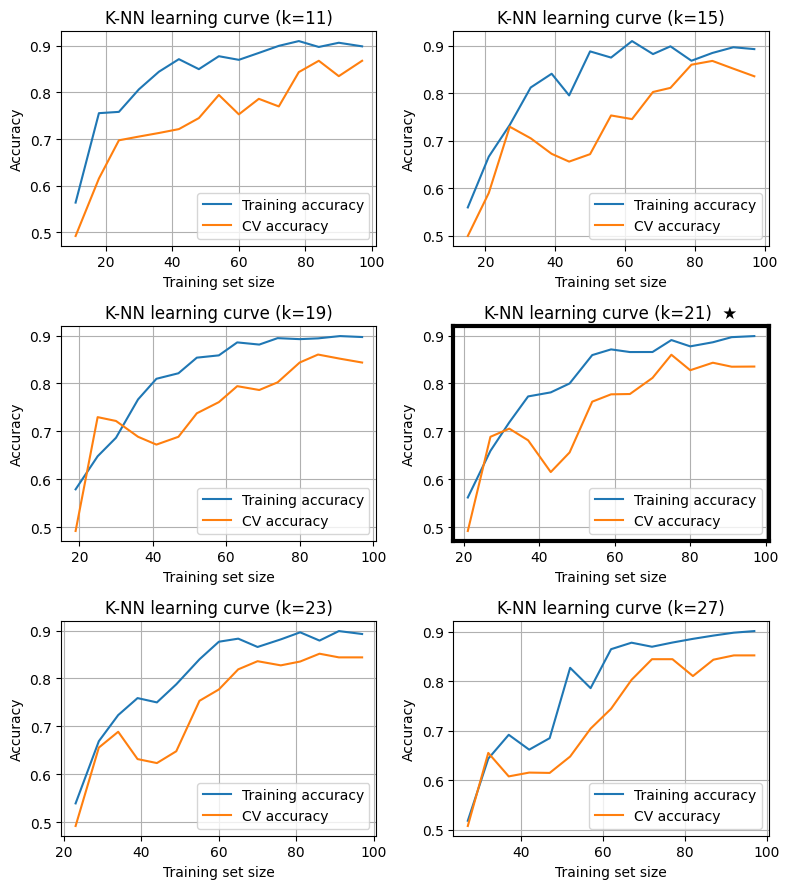

In [35]:

models=[]
for k in kc.k_neighborhood(best_k_3, len(monk_3_TR_labels)):
    models.append(KNeighborsClassifier(
        n_neighbors=k,
        weights=weights,
        metric=metric
    ))

kc.plot_knn_learning_curves_grid(
    models=models,
    X=monk_3_TR_features,
    y=monk_3_TR_labels,
    cv=default_cv,
    highlight_k=best_k_3
)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [23]:
model_3.fit(monk_3_TR_features, monk_3_TR_labels)
monk_3_TS_labels_pred = model_3.predict(monk_3_TS_features)

In [24]:
print(classification_report(monk_3_TS_labels, monk_3_TS_labels_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       204
           1       0.95      0.88      0.91       228

    accuracy                           0.91       432
   macro avg       0.91      0.91      0.91       432
weighted avg       0.91      0.91      0.91       432



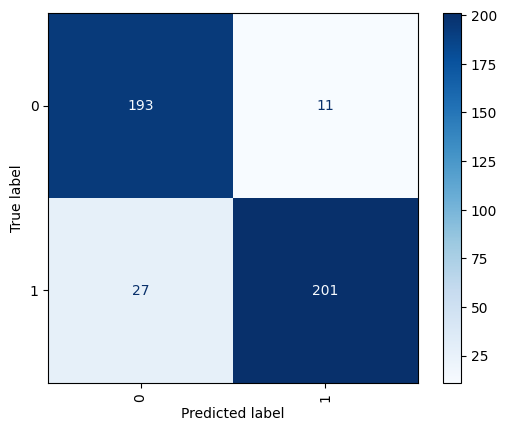

In [25]:
ConfusionMatrixDisplay.from_predictions(monk_3_TS_labels, monk_3_TS_labels_pred, xticks_rotation='vertical', cmap='Blues');